In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
RANDOM_STATE = 42
CSV_PATH = "findex_pakistan_features_target.csv"

In [2]:
# ---------------------------------------------------------------------
# 1. Load cleaned data
# ---------------------------------------------------------------------
data = pd.read_csv(CSV_PATH)
print(f"Loaded {data.shape[0]} rows, {data.shape[1]} columns")

Loaded 1000 rows, 24 columns


In [3]:
# ---------------------------------------------------------------------
# 2. Feature set for clustering
#    Use the SAME feature philosophy as Week 2 modelling: drop the
#    target and the variables that directly define it (account,
#    dig_account, anydigpayment, saved, fin22a, account_fin,
#    account_mob), so clusters reflect underlying structure rather than
#    trivially reproducing the tier boundaries.
# ---------------------------------------------------------------------
drop_cols = ["adoption_tier", "adoption_tier_label",
             "account", "dig_account", "anydigpayment", "saved", "fin22a",
             "account_fin", "account_mob"]
X = data.drop(columns=drop_cols)
print(f"\nFeatures used for clustering ({X.shape[1]}): {list(X.columns)}")


Features used for clustering (15): ['female', 'age', 'educ', 'inc_q', 'in_workforce', 'is_rural', 'con1', 'internet_use', 'merchantpay_dig', 'fin17b', 'fin17c', 'borrowed', 'fin22a_1', 'fin24a', 'fin24b']


In [4]:
# ---------------------------------------------------------------------
# 3. Standardize
# ---------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

k=2: silhouette=0.1675, davies-bouldin=2.0611 (lower better), calinski-harabasz=216.8 (higher better)
k=3: silhouette=0.1675, davies-bouldin=1.9831 (lower better), calinski-harabasz=194.9 (higher better)
k=4: silhouette=0.1442, davies-bouldin=2.0929 (lower better), calinski-harabasz=164.6 (higher better)
k=5: silhouette=0.1653, davies-bouldin=1.8624 (lower better), calinski-harabasz=145.5 (higher better)

Saved: kmeans_k_selection.png


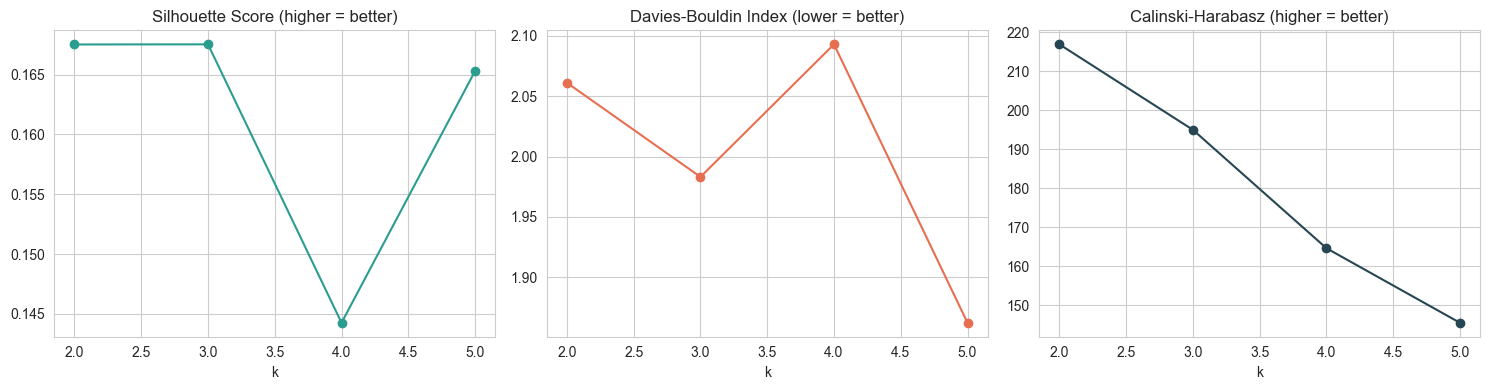

In [5]:
# ---------------------------------------------------------------------
# 4. Run k-means for k=2..5, score each with three validity metrics
# ---------------------------------------------------------------------
k_range = range(2, 6)
scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    scores.append({"k": k, "Silhouette": sil, "Davies-Bouldin": db, "Calinski-Harabasz": ch})
    print(f"k={k}: silhouette={sil:.4f}, davies-bouldin={db:.4f} (lower better), "
          f"calinski-harabasz={ch:.1f} (higher better)")

scores_df = pd.DataFrame(scores)
scores_df.to_csv("kmeans_k_selection.csv", index=False)

# Plot all three metrics vs k
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(scores_df["k"], scores_df["Silhouette"], marker="o", color="#2a9d8f")
axes[0].set_title("Silhouette Score (higher = better)")
axes[0].set_xlabel("k")
axes[1].plot(scores_df["k"], scores_df["Davies-Bouldin"], marker="o", color="#e76f51")
axes[1].set_title("Davies-Bouldin Index (lower = better)")
axes[1].set_xlabel("k")
axes[2].plot(scores_df["k"], scores_df["Calinski-Harabasz"], marker="o", color="#264653")
axes[2].set_title("Calinski-Harabasz (higher = better)")
axes[2].set_xlabel("k")
plt.tight_layout()
plt.savefig("kmeans_k_selection.png", dpi=150, bbox_inches="tight")
print("\nSaved: kmeans_k_selection.png")
plt.show()


In [6]:
# ---------------------------------------------------------------------
# 5. Select best k by silhouette score (primary metric per roadmap),
#    fit final model
# ---------------------------------------------------------------------
best_k = int(scores_df.loc[scores_df["Silhouette"].idxmax(), "k"])
print(f"\nSelected k = {best_k} (highest silhouette score)")

kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
data["cluster"] = kmeans_final.fit_predict(X_scaled)


Selected k = 3 (highest silhouette score)


In [7]:
# ---------------------------------------------------------------------
# 6. Cluster profiling
#    Mean adoption tier, urban/rural split, gender split, education
#    split per cluster, plus size.
# ---------------------------------------------------------------------
profile = data.groupby("cluster").agg(
    n=("cluster", "size"),
    mean_adoption_tier=("adoption_tier", "mean"),
    pct_female=("female", "mean"),
    pct_rural=("is_rural", "mean"),
    mean_educ=("educ", "mean"),
    mean_income_q=("inc_q", "mean"),
    pct_mobile_phone=("con1", "mean"),
    pct_internet_use=("internet_use", "mean"),
).round(3)
profile["pct_female"] *= 100
profile["pct_rural"] *= 100
profile["pct_mobile_phone"] *= 100
profile["pct_internet_use"] *= 100
profile["pct_of_sample"] = (profile["n"] / len(data) * 100).round(1)

print("\nCluster profile:")
print(profile.to_string())
profile.to_csv("cluster_profile.csv")

# Cross-tab: cluster vs adoption tier (does clustering rediscover the tiers?)
crosstab = pd.crosstab(data["cluster"], data["adoption_tier_label"], normalize="index") * 100
crosstab = crosstab.round(1)
print("\nCluster vs Adoption Tier (% within cluster):")
print(crosstab.to_string())
crosstab.to_csv("cluster_vs_tier_crosstab.csv")


Cluster profile:
           n  mean_adoption_tier  pct_female  pct_rural  mean_educ  mean_income_q  pct_mobile_phone  pct_internet_use  pct_of_sample
cluster                                                                                                                             
0        431               0.209        96.3       51.0      1.258          2.995              28.3               9.7           43.1
1        443               0.797        16.3       46.0      1.600          3.456              98.0              62.3           44.3
2        126               2.921        10.3       28.6      1.984          4.175              98.4              93.7           12.6

Cluster vs Adoption Tier (% within cluster):
adoption_tier_label  Advanced  Basic  Digitally Engaged  Excluded
cluster                                                          
0                         2.6    3.0                5.1      89.3
1                        15.1    1.8               16.3      66.8
2      

In [8]:
# ---------------------------------------------------------------------
# 7. H1 check: does a cluster emerge that resembles the
#    'account-holder who never uses it' (dormant) group?
#    Look at each cluster's mean on con1/internet_use (access-like)
#    vs the behavioural columns -- a dormant cluster would show
#    moderate-to-high access but low digital financial behaviour.
# ---------------------------------------------------------------------
behaviour_cols = ["merchantpay_dig", "fin17b", "fin17c", "borrowed", "fin22a_1"]
access_cols = ["con1", "internet_use"]
cluster_behaviour = data.groupby("cluster")[behaviour_cols + access_cols].mean().round(3)
print("\nCluster access vs behaviour means (look for high access + low behaviour = dormant-like):")
print(cluster_behaviour.to_string())


Cluster access vs behaviour means (look for high access + low behaviour = dormant-like):
         merchantpay_dig  fin17b  fin17c  borrowed  fin22a_1   con1  internet_use
cluster                                                                          
0                  0.000   0.007   0.084     0.629     0.000  0.283         0.097
1                  0.005   0.020   0.181     0.704     0.005  0.980         0.623
2                  0.460   0.849   0.563     0.841     0.397  0.984         0.937



PCA explained variance ratio: [0.25787318 0.10483061]
Total variance explained by 2 components: 36.3%
Saved: cluster_pca_scatter.png


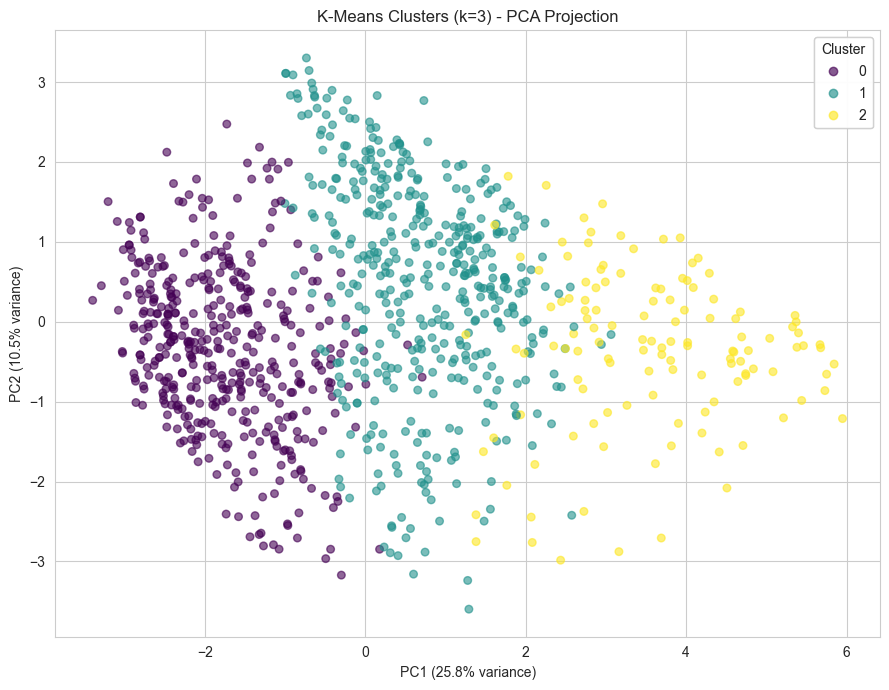


Top PC1 contributors:
                   PC1       PC2
internet_use  0.363925 -0.132322
female       -0.357172 -0.366274
con1          0.339082  0.209969
fin17b        0.325306 -0.048788
in_workforce  0.308461  0.433096
fin24a        0.273273 -0.186887


In [9]:
# ---------------------------------------------------------------------
# 8. 2D visualization via PCA
# ---------------------------------------------------------------------
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"\nPCA explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained by 2 components: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(9, 7))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=data["cluster"], cmap="viridis",
                      alpha=0.6, s=30)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title(f"K-Means Clusters (k={best_k}) - PCA Projection")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend1)
plt.tight_layout()
plt.savefig("cluster_pca_scatter.png", dpi=150, bbox_inches="tight")
print("Saved: cluster_pca_scatter.png")
plt.show()

# Loadings: which original features drive PC1/PC2 (helps name the axes)
loadings = pd.DataFrame(pca.components_.T, columns=["PC1", "PC2"], index=X.columns)
loadings["abs_PC1"] = loadings["PC1"].abs()
print("\nTop PC1 contributors:")
print(loadings.sort_values("abs_PC1", ascending=False)[["PC1", "PC2"]].head(6).to_string())


Saved: cluster_profile_heatmap.png


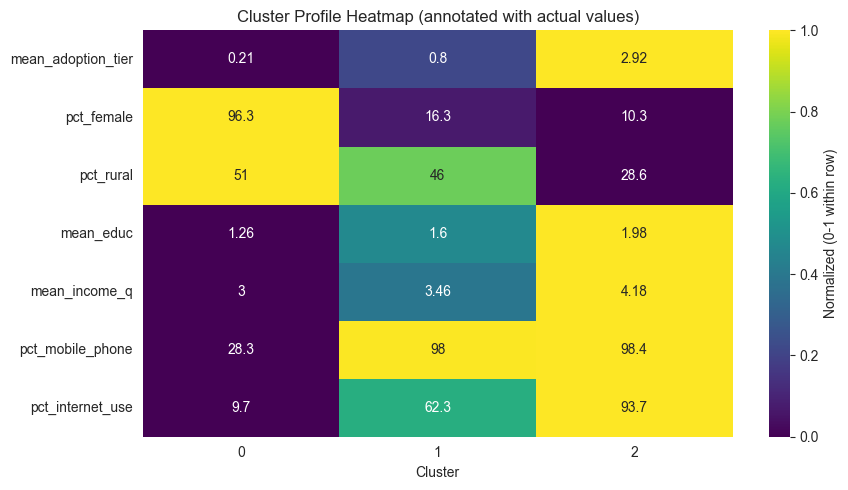

In [10]:
# ---------------------------------------------------------------------
# 9. Cluster profile heatmap (normalized) for quick visual comparison
# ---------------------------------------------------------------------
profile_for_heatmap = profile.drop(columns=["n", "pct_of_sample"])
profile_normalized = (profile_for_heatmap - profile_for_heatmap.min()) / \
                      (profile_for_heatmap.max() - profile_for_heatmap.min())

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(profile_normalized.T, annot=profile_for_heatmap.T.round(2), fmt="g",
            cmap="viridis", cbar_kws={"label": "Normalized (0-1 within row)"}, ax=ax)
ax.set_title("Cluster Profile Heatmap (annotated with actual values)")
ax.set_xlabel("Cluster")
plt.tight_layout()
plt.savefig("cluster_profile_heatmap.png", dpi=150, bbox_inches="tight")
print("Saved: cluster_profile_heatmap.png")
plt.show()

In [11]:
# ---------------------------------------------------------------------
# 10. Save final dataset with cluster labels for the write-up
# ---------------------------------------------------------------------
data.to_csv("findex_pakistan_with_clusters.csv", index=False)
print("\nWeek 3 complete. Outputs saved:")
print("  - kmeans_k_selection.csv / .png")
print("  - cluster_profile.csv")
print("  - cluster_vs_tier_crosstab.csv")
print("  - cluster_pca_scatter.png")
print("  - cluster_profile_heatmap.png")
print("  - findex_pakistan_with_clusters.csv")


Week 3 complete. Outputs saved:
  - kmeans_k_selection.csv / .png
  - cluster_profile.csv
  - cluster_vs_tier_crosstab.csv
  - cluster_pca_scatter.png
  - cluster_profile_heatmap.png
  - findex_pakistan_with_clusters.csv
